正在加载K线数据...
📂 使用K线数据文件: binance_daily_klines_20251218.csv
✅ 数据加载完成，共 108,839 条记录，78 个币种

正在计算 ETHUSDT 参考价格...
📊 ETHUSDT 数据范围: 2020-01-01 ~ 2025-12-17
📊 总交易日数: 2178
🔄 计算换手率（窗口=30天）...
🔄 计算参考价格RP...
✅ 计算完成

绘制 ETHUSDT 完整时间范围图表...


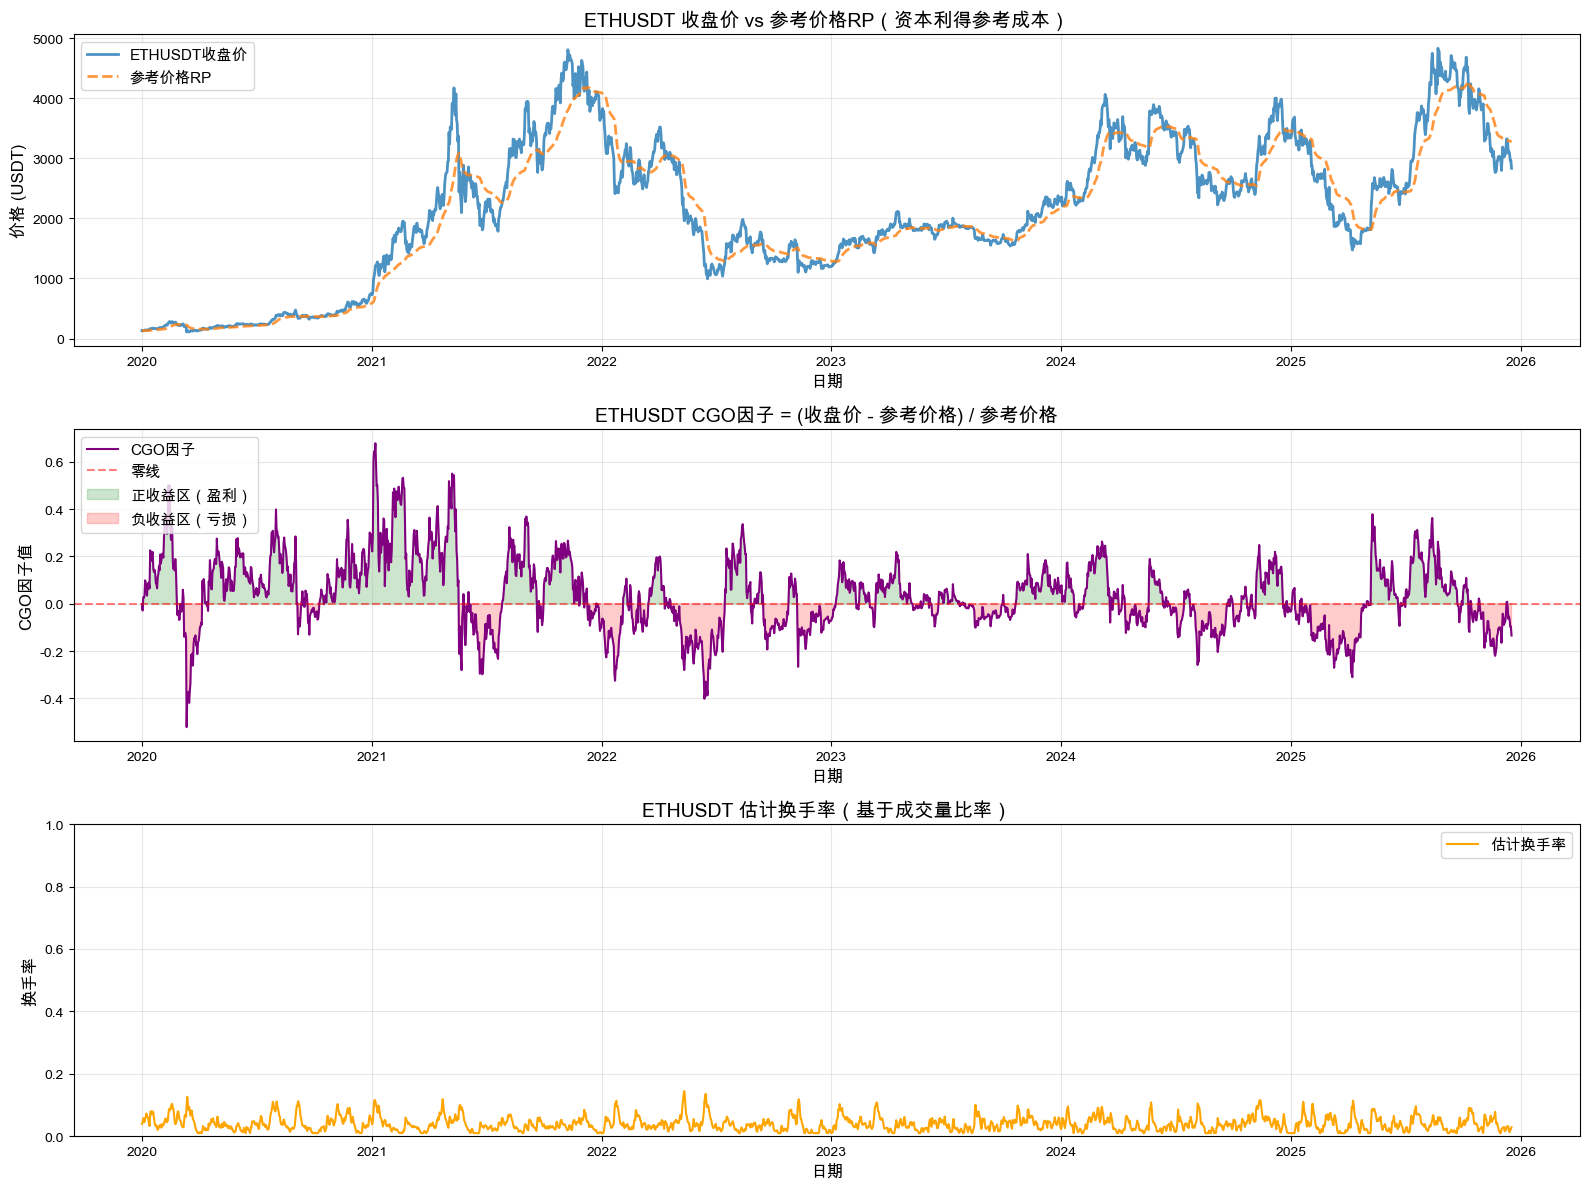


ETHUSDT 参考价格统计信息
数据时间范围: 2020-01-01 ~ 2025-12-17
总交易日数: 2178

📈 收盘价统计:
  均值: $2,157.40
  标准差: $1,179.41
  最小值: $107.82 (2020-03-12)
  最大值: $4,832.07 (2025-08-22)

💼 参考价格RP统计:
  均值: $2,116.34
  标准差: $1,141.08
  最小值: $130.81
  最大值: $4,279.26

📊 CGO因子统计:
  均值: 0.0360
  标准差: 0.1468
  最小值: -0.5209 (最大亏损)
  最大值: 0.6776 (最大盈利)
  正值比例: 56.52% (盈利天数占比)

🔄 换手率统计:
  均值: 0.0402
  标准差: 0.0227
  最小值: 0.0100
  最大值: 0.1448

绘制 ETHUSDT 最近一年数据...


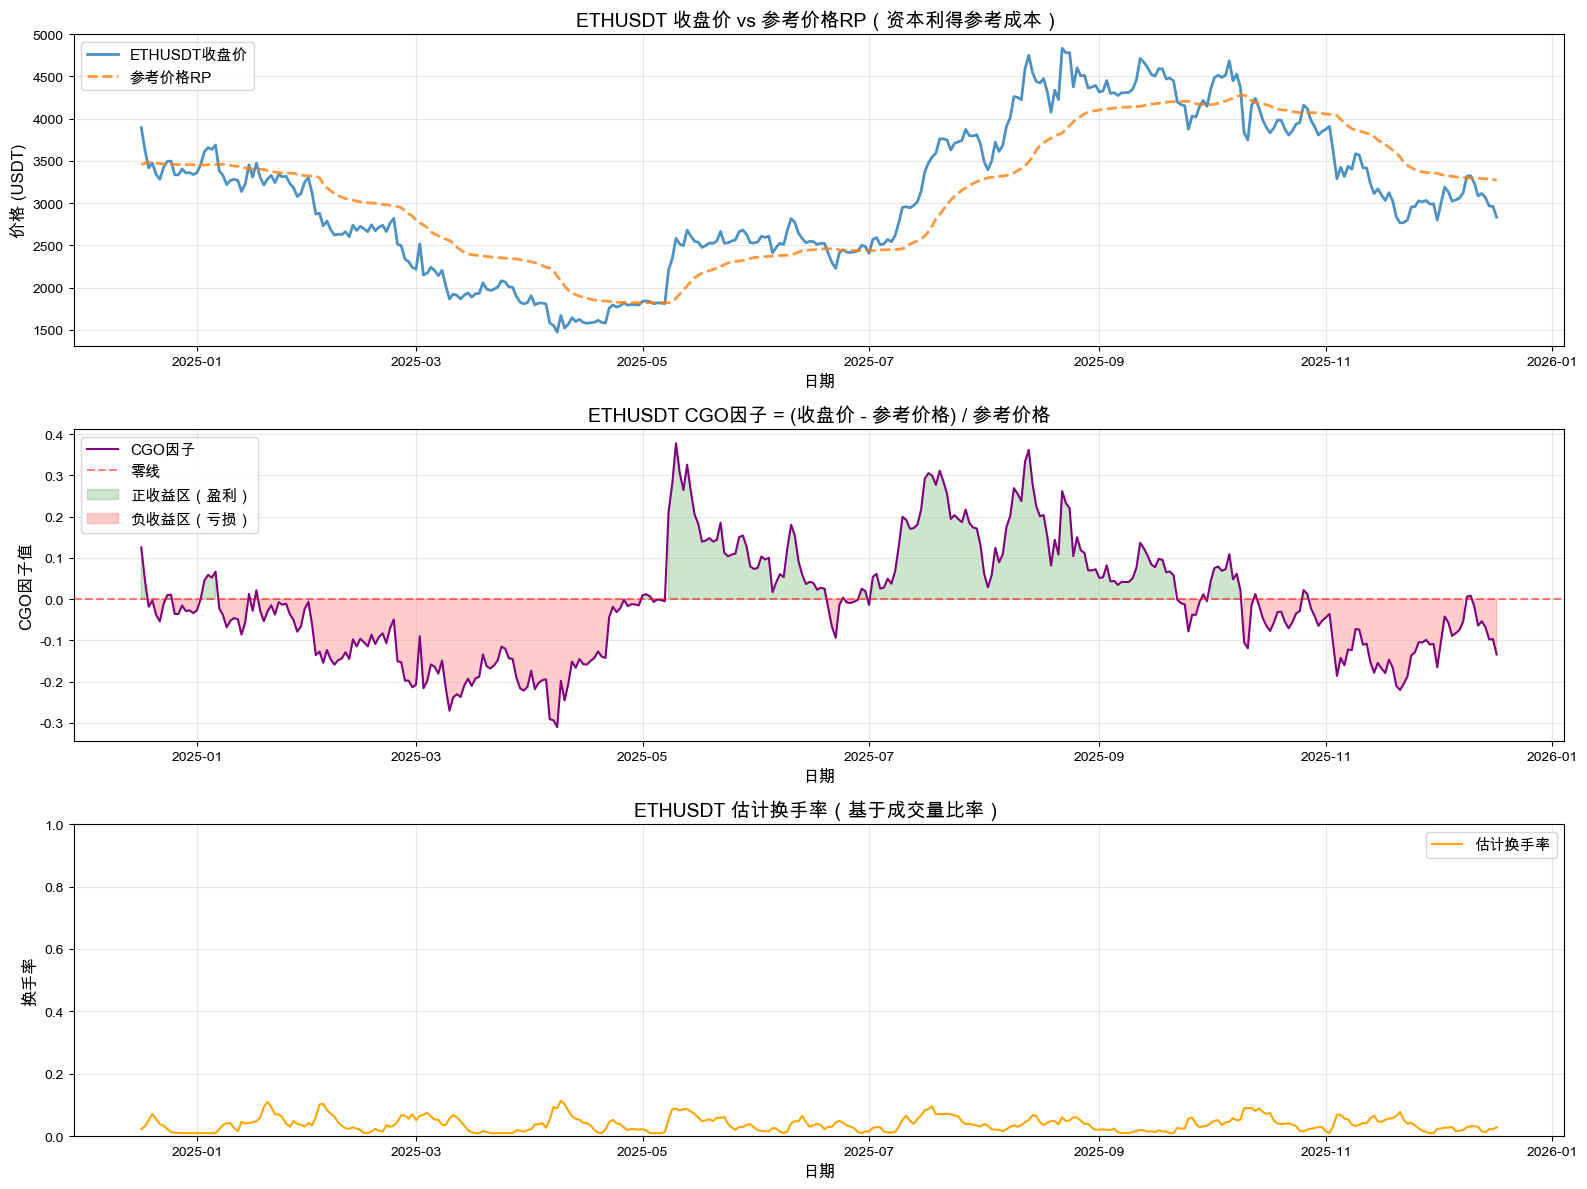


ETHUSDT 参考价格统计信息
数据时间范围: 2024-12-17 ~ 2025-12-17
总交易日数: 366

📈 收盘价统计:
  均值: $3,086.20
  标准差: $870.37
  最小值: $1,473.41 (2025-04-08)
  最大值: $4,832.07 (2025-08-22)

💼 参考价格RP统计:
  均值: $3,101.11
  标准差: $749.06
  最小值: $1,820.03
  最大值: $4,279.26

📊 CGO因子统计:
  均值: -0.0069
  标准差: 0.1359
  最小值: -0.3100 (最大亏损)
  最大值: 0.3780 (最大盈利)
  正值比例: 42.90% (盈利天数占比)

🔄 换手率统计:
  均值: 0.0390
  标准差: 0.0229
  最小值: 0.0100
  最大值: 0.1140

绘制 ETHUSDT 最近半年数据...


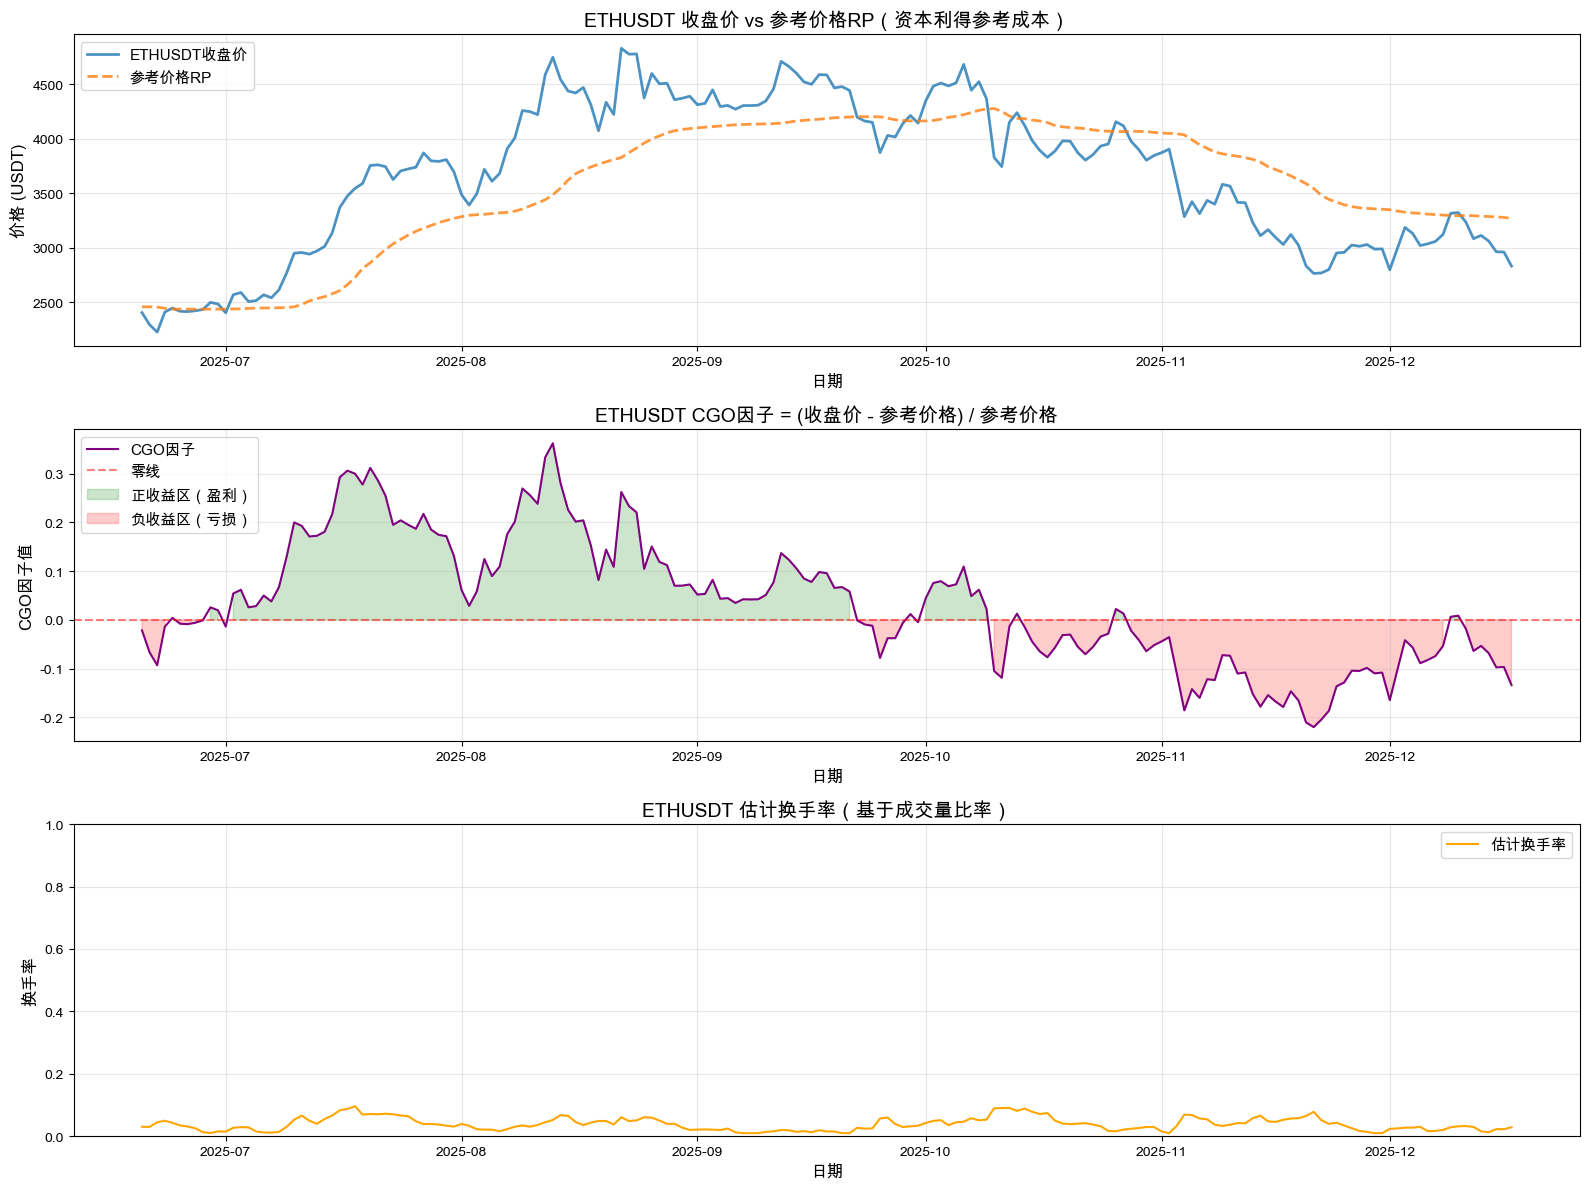


ETHUSDT 参考价格统计信息
数据时间范围: 2025-06-20 ~ 2025-12-17
总交易日数: 181

📈 收盘价统计:
  均值: $3,669.64
  标准差: $688.87
  最小值: $2,227.70 (2025-06-22)
  最大值: $4,832.07 (2025-08-22)

💼 参考价格RP统计:
  均值: $3,569.62
  标准差: $601.04
  最小值: $2,437.64
  最大值: $4,279.26

📊 CGO因子统计:
  均值: 0.0327
  标准差: 0.1292
  最小值: -0.2200 (最大亏损)
  最大值: 0.3620 (最大盈利)
  正值比例: 55.25% (盈利天数占比)

🔄 换手率统计:
  均值: 0.0386
  标准差: 0.0206
  最小值: 0.0100
  最大值: 0.0963


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os
import sys

# 设置中文显示
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# ========== 配置：可以修改这里选择要分析的币种 ==========
SYMBOL = 'ETHUSDT'  # 可以改为 'ETHUSDT', 'BNBUSDT' 等

# ========== 1. 加载数据（修正版）==========
def load_kline_df(path=None):
    """加载K线数据"""
    if path is None:
        # 使用实际的数据路径
        kline_dir = Path("../kline_data")  # notebook在data目录下，所以用相对路径
        
        # 查找最新的K线文件（排除统计文件）
        files = sorted([
            f for f in kline_dir.glob("binance_daily_klines_*.csv")
            if '_daily_token_count' not in f.name
        ])
        
        if not files:
            raise FileNotFoundError(f"未找到K线数据文件，搜索路径: {kline_dir.absolute()}")
        
        path = files[-1]
        print(f"📂 使用K线数据文件: {path.name}")
    
    df = pd.read_csv(path)
    df["date"] = pd.to_datetime(df["date"])
    df = df.sort_values(["symbol", "date"])
    return df

# ========== 2. 参考价格计算函数 ==========
def calculate_rp_recursive(vwap_arr, turnover_arr):
    """
    使用递归方式计算参考价格 RP (Reference Price)
    逻辑: RP_t = RP_{t-1} * (1 - V_{t-1}) + P_{t-1} * V_{t-1}
    
    解释：
    - RP代表"参考持仓成本"
    - 每天一部分仓位(V_{t-1})按昨日价格(P_{t-1})换手
    - 剩余仓位(1-V_{t-1})保持原成本(RP_{t-1})
    """
    T = len(vwap_arr)
    rp_arr = np.zeros(T)
    rp_arr[0] = vwap_arr[0]  # 初始值

    curr_rp = vwap_arr[0]
    for t in range(1, T):
        v_prev = turnover_arr[t-1]
        p_prev = vwap_arr[t-1]
        curr_rp = curr_rp * (1 - v_prev) + p_prev * v_prev
        rp_arr[t] = curr_rp
        
    return rp_arr

def calculate_turnover_strict(volume_series, window=30):
    """
    基于成交量占比的换手率估计
    更符合真实市场特征
    """
    # 计算滚动平均成交量
    avg_volume = volume_series.rolling(window=window, min_periods=1).mean()
    
    # 当日成交量 / 平均成交量的比率
    volume_ratio = volume_series / (avg_volume + 1e-8)
    
    # 映射到换手率（使用更保守的映射）
    # 假设成交量等于平均值时，换手率为5%
    # 成交量是平均值2倍时，换手率约为15%
    base_rate = 0.04
    sensitivity = 0.15
    turnover = base_rate + sensitivity * np.tanh((volume_ratio - 1) / 2)
    
    # 平滑处理
    turnover = turnover.ewm(span=5, adjust=False).mean()
    
    # 截断在合理范围
    turnover = turnover.clip(0.01, 0.4)
    
    return turnover


# ========== 3. 为指定币种计算参考价格 ==========
def calculate_reference_price(df, symbol='BTCUSDT', window=60):
    """
    为指定币种计算参考价格
    
    Parameters:
    - df: K线数据DataFrame
    - symbol: 币种符号，如 'BTCUSDT', 'ETHUSDT' 等
    - window: 换手率计算窗口（默认60天）
    """
    # 提取指定币种数据
    coin_df = df[df['symbol'] == symbol].copy().sort_values('date').reset_index(drop=True)
    
    if len(coin_df) == 0:
        raise ValueError(f"数据中没有找到 {symbol}")
    
    print(f"📊 {symbol} 数据范围: {coin_df['date'].min().date()} ~ {coin_df['date'].max().date()}")
    print(f"📊 总交易日数: {len(coin_df)}")
    
    # 计算VWAP
    if 'quote_volume' in coin_df.columns and 'volume' in coin_df.columns:
        coin_df['vwap'] = np.where(
            coin_df['volume'] > 0, 
            coin_df['quote_volume'] / coin_df['volume'], 
            coin_df['close']
        )
    else:
        coin_df['vwap'] = coin_df['close']
    
    # 计算换手率
    print(f"🔄 计算换手率（窗口={window}天）...")
    coin_df['turnover'] = calculate_turnover_strict(coin_df['volume'], window=window)
    
    # 计算参考价格RP
    print(f"🔄 计算参考价格RP...")
    vwap_values = coin_df['vwap'].values
    turnover_values = coin_df['turnover'].values
    coin_df['rp'] = calculate_rp_recursive(vwap_values, turnover_values)
    
    # 计算CGO因子
    coin_df['cgo'] = (coin_df['close'] - coin_df['rp']) / (coin_df['rp'] + 1e-8)
    
    return coin_df

# ========== 4. 绘图函数 ==========
def plot_with_reference_price(coin_df, symbol='BTCUSDT', start_date=None, end_date=None):
    """
    绘制币种收盘价和参考价格RP对比图
    
    Parameters:
    - coin_df: 包含date, close, rp列的DataFrame
    - symbol: 币种符号，用于标题显示
    - start_date: 起始日期（可选）
    - end_date: 结束日期（可选）
    """
    # 日期筛选
    plot_df = coin_df.copy()
    if start_date:
        plot_df = plot_df[plot_df['date'] >= start_date]
    if end_date:
        plot_df = plot_df[plot_df['date'] <= end_date]
    
    # 创建图表
    fig, axes = plt.subplots(3, 1, figsize=(16, 12))
    
    # ===== 子图1: 价格对比 =====
    ax1 = axes[0]
    ax1.plot(plot_df['date'], plot_df['close'], label=f'{symbol}收盘价', linewidth=2, alpha=0.8, color='#1f77b4')
    ax1.plot(plot_df['date'], plot_df['rp'], label='参考价格RP', linewidth=2, alpha=0.8, linestyle='--', color='#ff7f0e')
    ax1.set_xlabel('日期', fontsize=12)
    ax1.set_ylabel('价格 (USDT)', fontsize=12)
    ax1.set_title(f'{symbol} 收盘价 vs 参考价格RP（资本利得参考成本）', fontsize=14, fontweight='bold')
    ax1.legend(fontsize=11, loc='upper left')
    ax1.grid(True, alpha=0.3)
    
    # ===== 子图2: CGO因子（收盘价-参考价格）/参考价格 =====
    ax2 = axes[1]
    ax2.plot(plot_df['date'], plot_df['cgo'], label='CGO因子', color='purple', linewidth=1.5)
    ax2.axhline(y=0, color='red', linestyle='--', alpha=0.5, label='零线')
    ax2.fill_between(plot_df['date'], 0, plot_df['cgo'], 
                      where=(plot_df['cgo'] > 0), color='green', alpha=0.2, label='正收益区（盈利）')
    ax2.fill_between(plot_df['date'], 0, plot_df['cgo'], 
                      where=(plot_df['cgo'] <= 0), color='red', alpha=0.2, label='负收益区（亏损）')
    ax2.set_xlabel('日期', fontsize=12)
    ax2.set_ylabel('CGO因子值', fontsize=12)
    ax2.set_title(f'{symbol} CGO因子 = (收盘价 - 参考价格) / 参考价格', fontsize=14, fontweight='bold')
    ax2.legend(fontsize=11, loc='upper left')
    ax2.grid(True, alpha=0.3)
    
    # ===== 子图3: 换手率 =====
    ax3 = axes[2]
    ax3.plot(plot_df['date'], plot_df['turnover'], label='估计换手率', color='orange', linewidth=1.5)
    ax3.set_xlabel('日期', fontsize=12)
    ax3.set_ylabel('换手率', fontsize=12)
    ax3.set_title(f'{symbol} 估计换手率（基于成交量比率）', fontsize=14, fontweight='bold')
    ax3.legend(fontsize=11, loc='upper right')
    ax3.grid(True, alpha=0.3)
    ax3.set_ylim([0, 1])  # 换手率范围0-1
    
    plt.tight_layout()
    plt.show()
    
    # 打印统计信息
    print("\n" + "="*60)
    print(f"{symbol} 参考价格统计信息")
    print("="*60)
    print(f"数据时间范围: {plot_df['date'].min().date()} ~ {plot_df['date'].max().date()}")
    print(f"总交易日数: {len(plot_df)}")
    print(f"\n📈 收盘价统计:")
    print(f"  均值: ${plot_df['close'].mean():,.2f}")
    print(f"  标准差: ${plot_df['close'].std():,.2f}")
    print(f"  最小值: ${plot_df['close'].min():,.2f} ({plot_df.loc[plot_df['close'].idxmin(), 'date'].date()})")
    print(f"  最大值: ${plot_df['close'].max():,.2f} ({plot_df.loc[plot_df['close'].idxmax(), 'date'].date()})")
    
    print(f"\n💼 参考价格RP统计:")
    print(f"  均值: ${plot_df['rp'].mean():,.2f}")
    print(f"  标准差: ${plot_df['rp'].std():,.2f}")
    print(f"  最小值: ${plot_df['rp'].min():,.2f}")
    print(f"  最大值: ${plot_df['rp'].max():,.2f}")
    
    print(f"\n📊 CGO因子统计:")
    print(f"  均值: {plot_df['cgo'].mean():.4f}")
    print(f"  标准差: {plot_df['cgo'].std():.4f}")
    print(f"  最小值: {plot_df['cgo'].min():.4f} (最大亏损)")
    print(f"  最大值: {plot_df['cgo'].max():.4f} (最大盈利)")
    print(f"  正值比例: {(plot_df['cgo'] > 0).mean():.2%} (盈利天数占比)")
    
    print(f"\n🔄 换手率统计:")
    print(f"  均值: {plot_df['turnover'].mean():.4f}")
    print(f"  标准差: {plot_df['turnover'].std():.4f}")
    print(f"  最小值: {plot_df['turnover'].min():.4f}")
    print(f"  最大值: {plot_df['turnover'].max():.4f}")
    print("="*60)

# ========== 5. 主执行代码 ==========
# 加载数据
print("正在加载K线数据...")
df = load_kline_df()
print(f"✅ 数据加载完成，共 {len(df):,} 条记录，{df['symbol'].nunique()} 个币种")

# 计算指定币种的参考价格（使用30天窗口）
print(f"\n正在计算 {SYMBOL} 参考价格...")
coin_df = calculate_reference_price(df, symbol=SYMBOL, window=30)
print(f"✅ 计算完成")

# 绘图 - 全部数据
print("\n" + "="*60)
print(f"绘制 {SYMBOL} 完整时间范围图表...")
print("="*60)
plot_with_reference_price(coin_df, symbol=SYMBOL)

# 可选：绘制最近一年的数据
print("\n" + "="*60)
print(f"绘制 {SYMBOL} 最近一年数据...")
print("="*60)
one_year_ago = coin_df['date'].max() - pd.Timedelta(days=365)
plot_with_reference_price(coin_df, symbol=SYMBOL, start_date=one_year_ago)

# 可选：绘制最近半年的数据
print("\n" + "="*60)
print(f"绘制 {SYMBOL} 最近半年数据...")
print("="*60)
six_months_ago = coin_df['date'].max() - pd.Timedelta(days=180)
plot_with_reference_price(coin_df, symbol=SYMBOL, start_date=six_months_ago)